# E-Commerce Sales Intelligence Dashboard

## Objective

This project analyzes e-commerce sales data using Python and Pandas to identify business insights through data visualization and exploratory data analysis.

## Project Workflow

1. Import Libraries
2. Load Dataset
3. Dataset Overview
4. Data Cleaning
5. Feature Engineering
6. Exploratory Data Analysis (EDA)
7. Business Insights
8. Conclusion

In [8]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load e-commerce sales dataset
file_path = ""


# Read Excel dataset using Pandas
df = pd.read_excel(file_path)

# Display first five records
df.head()

,Date,Customer ID,Product Category,Product Name,Quantity Sold,Price,Discount Applied,Payment Method,Total Sales
0,2024-01-01,b269ef97,Books,Laptop,3,352.10,0.16,Credit Card,887.2920
1,2024-01-02,791440fc,Electronics,Novel,4,272.69,0.14,PayPal,938.0536
2,2024-01-03,cc917c87,Clothing,Vacuum,1,161.67,0.01,Credit Card,160.0533
3,2024-01-04,39386f53,Clothing,Board Game,3,408.76,0.10,Credit Card,1103.6520
4,2024-01-05,59e8fa53,Books,Shoes,3,345.52,0.11,Credit Card,922.5384


In [9]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 9)


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              1000 non-null   datetime64[ns]
 1   Customer ID       1000 non-null   object        
 2   Product Category  1000 non-null   object        
 3   Product Name      1000 non-null   object        
 4   Quantity Sold     1000 non-null   int64         
 5   Price             1000 non-null   float64       
 6   Discount Applied  1000 non-null   float64       
 7   Payment Method    1000 non-null   object        
 8   Total Sales       1000 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 70.4+ KB


In [11]:
df.describe()

,Date,Quantity Sold,Price,Discount Applied,Total Sales
count,1000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2025-05-14 12:00:00,2.534000,254.879690,0.149560,548.479394
min,2024-01-01 00:00:00,1.000000,12.270000,0.000000,10.504000
25%,2024-09-06 18:00:00,1.000000,126.095000,0.080000,219.045225
50%,2025-05-14 12:00:00,3.000000,255.270000,0.150000,425.717500
75%,2026-01-19 06:00:00,4.000000,377.367500,0.220000,809.259225
max,2026-09-26 00:00:00,4.000000,499.860000,0.300000,1874.247200
std,NaN,1.151595,142.982197,0.086101,422.453904


In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [2]:
# Checking for Missing values
df.isnull().sum()


,0
Date,0
Customer ID,0
Product Category,0
Product Name,0
Quantity Sold,0
Price,0
Discount Applied,0
Payment Method,0
Total Sales,0


In [16]:
# Convert date column to proper format
df["Date"] = pd.to_datetime(df["Date"] , format="%d-%m-%Y")

In [17]:
# Creating a new column for revenue
df["Revenue"] = df["Quantity Sold"] * df["Price"] * (1 - df["Discount Applied"])

In [18]:
df["Month"] = df["Date"].dt.month_name()
df["Year"] = df["Date"].dt.year

df[["Date","Month","Year","Revenue"]].head()

,Date,Month,Year,Revenue
0,2024-01-01,January,2024,887.2920
1,2024-01-02,January,2024,938.0536
2,2024-01-03,January,2024,160.0533
3,2024-01-04,January,2024,1103.6520
4,2024-01-05,January,2024,922.5384


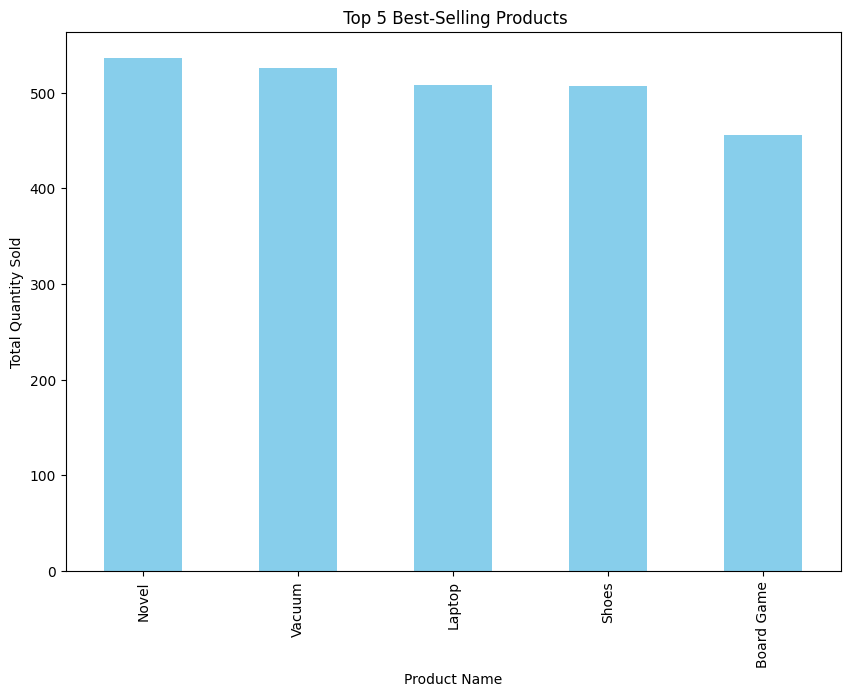

In [19]:
"""
(EDA) Exploratory Data Analysis

Top 5 best selling products

"""
top_products = df.groupby("Product Name")["Quantity Sold"].sum().sort_values(ascending=False).head(5)

# Plot
plt.figure(figsize=(10,7))
top_products.plot(kind="bar", color="skyblue")
plt.title(" Top 5 Best-Selling Products")
plt.ylabel("Total Quantity Sold")
plt.xlabel("Product Name")
plt.show()

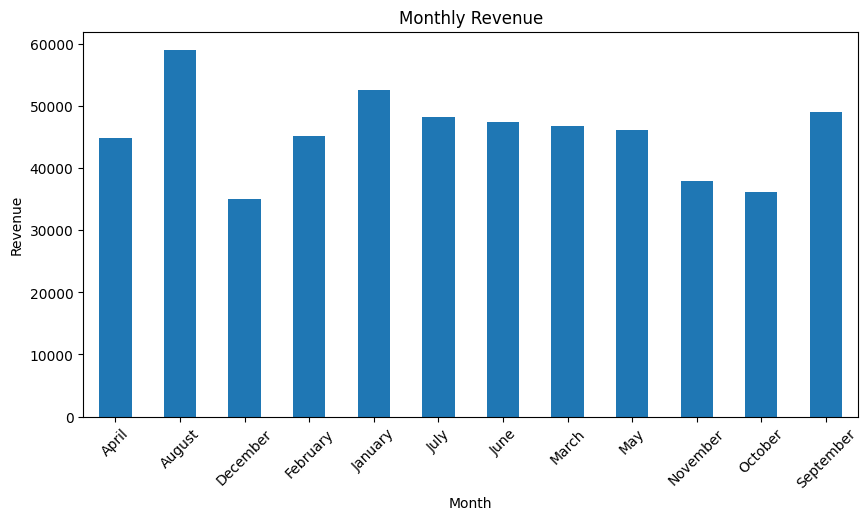

In [20]:
monthly_revenue = df.groupby("Month")["Revenue"].sum()

plt.figure(figsize=(10,5))
monthly_revenue.plot(kind="bar")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

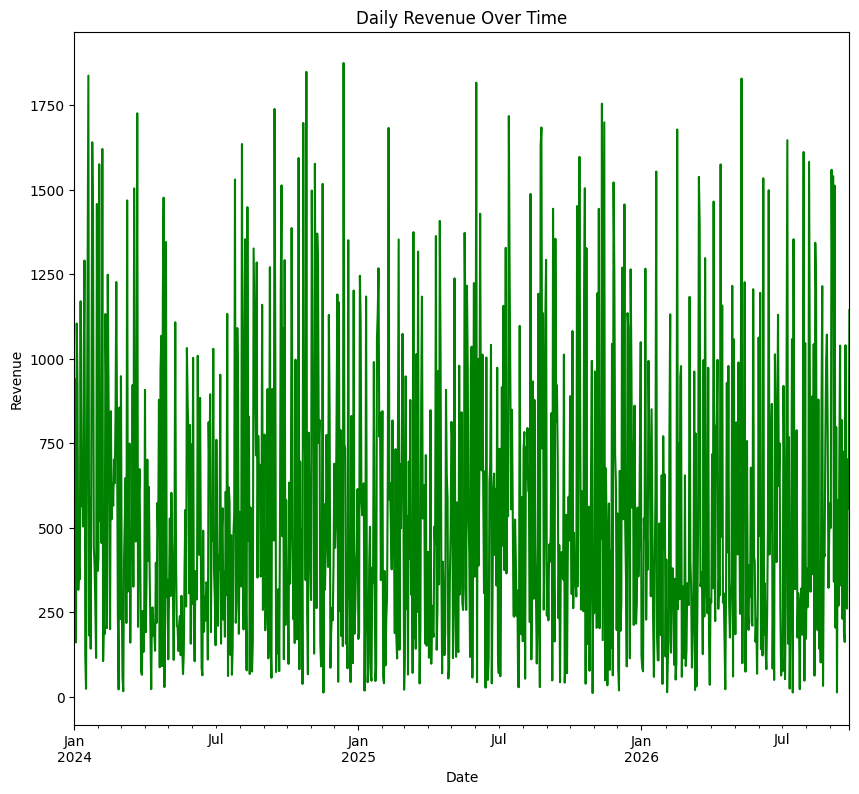

In [6]:
# Sales Trend over Time

df.groupby("Date")["Revenue"].sum().plot(figsize=(10,9), title="Daily Revenue Over Time", color="green")
plt.ylabel("Revenue")
plt.show()

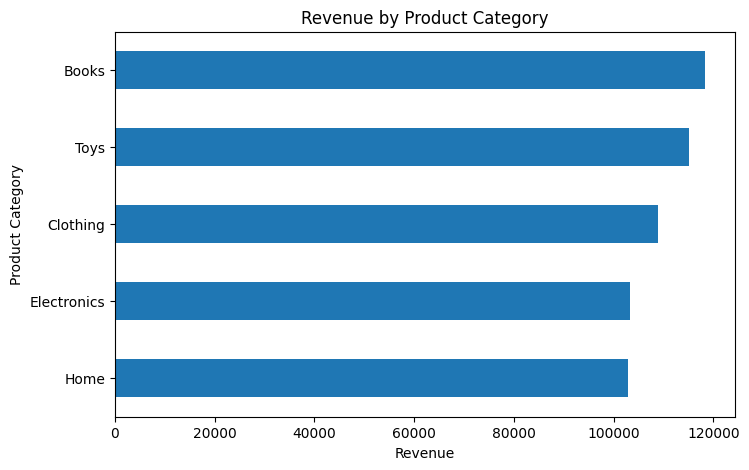

In [22]:
category = df.groupby("Product Category")["Revenue"].sum().sort_values()

plt.figure(figsize=(8,5))
category.plot(kind="barh")
plt.title("Revenue by Product Category")
plt.xlabel("Revenue")
plt.show()

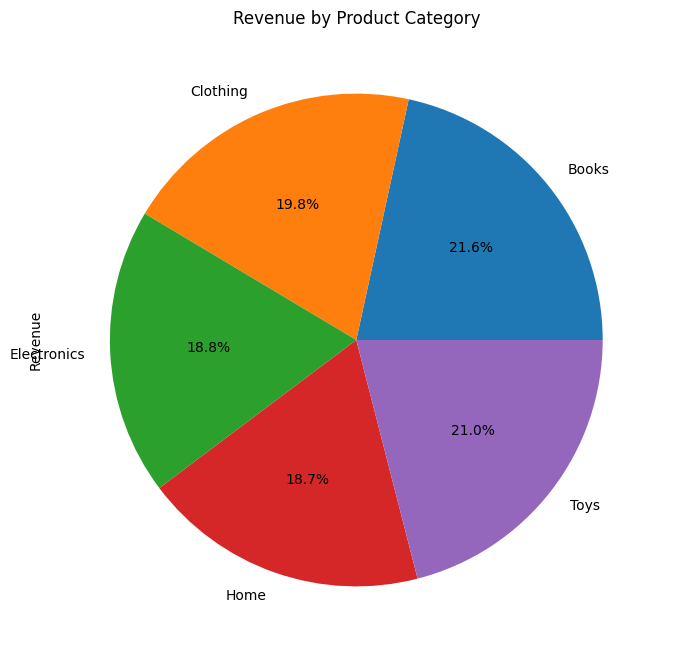

In [7]:
# Sales breakdown by Category
df.groupby("Product Category")["Revenue"].sum().plot(kind="pie", autopct="%1.1f%%", figsize=(8,8))
plt.title('Revenue by Product Category')
plt.show()

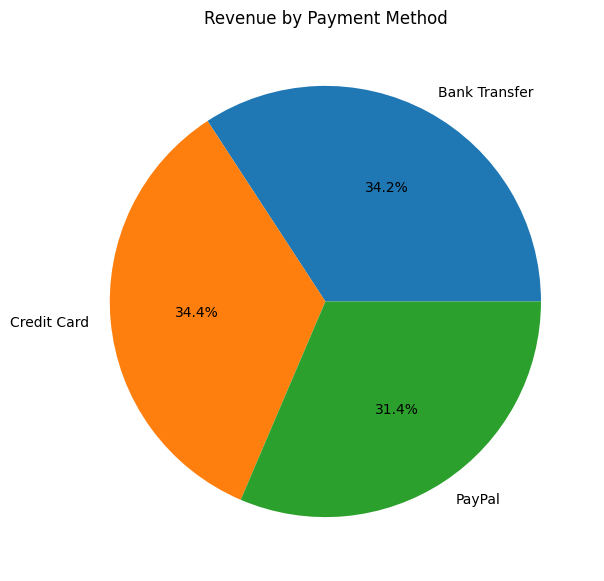

In [21]:
payment = df.groupby("Payment Method")["Revenue"].sum()

plt.figure(figsize=(7,7))
payment.plot(kind="pie", autopct="%1.1f%%")
plt.title("Revenue by Payment Method")
plt.ylabel("")
plt.show()

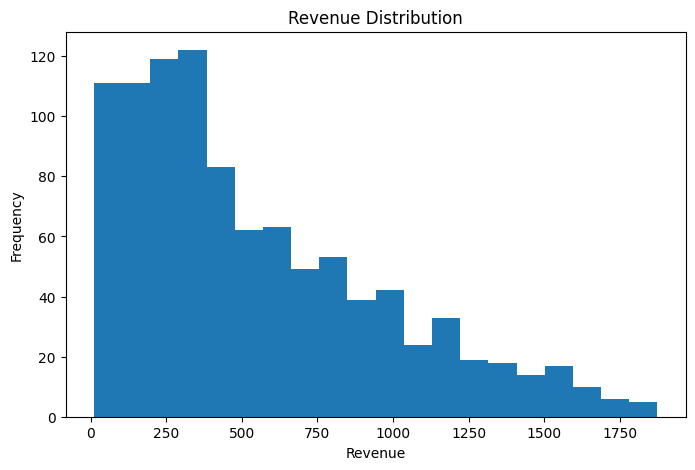

In [23]:
plt.figure(figsize=(8,5))
plt.hist(df["Revenue"], bins=20)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

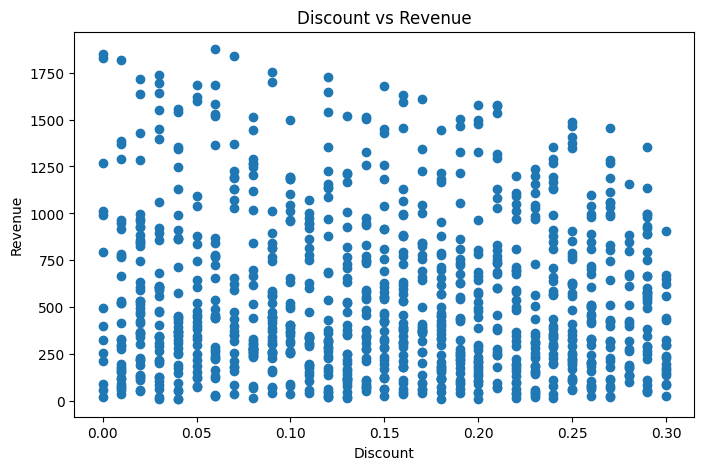

In [24]:
plt.figure(figsize=(8,5))
plt.scatter(df["Discount Applied"], df["Revenue"])
plt.title("Discount vs Revenue")
plt.xlabel("Discount")
plt.ylabel("Revenue")
plt.show()

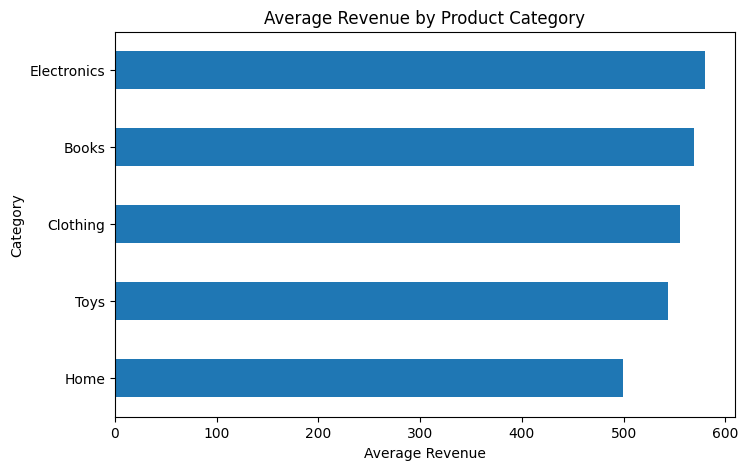

In [25]:
avg_category = df.groupby("Product Category")["Revenue"].mean().sort_values()

plt.figure(figsize=(8,5))
avg_category.plot(kind="barh")
plt.title("Average Revenue by Product Category")
plt.xlabel("Average Revenue")
plt.ylabel("Category")
plt.show()

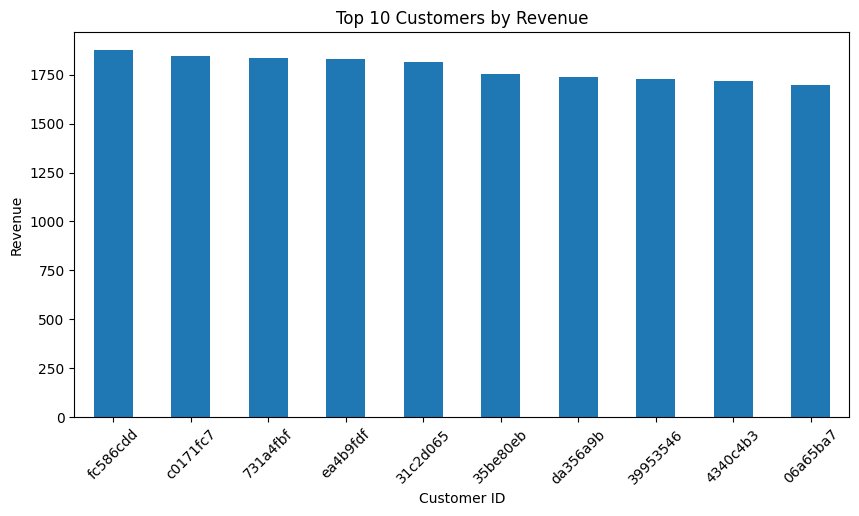

In [26]:
top_customers = df.groupby("Customer ID")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_customers.plot(kind="bar")
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

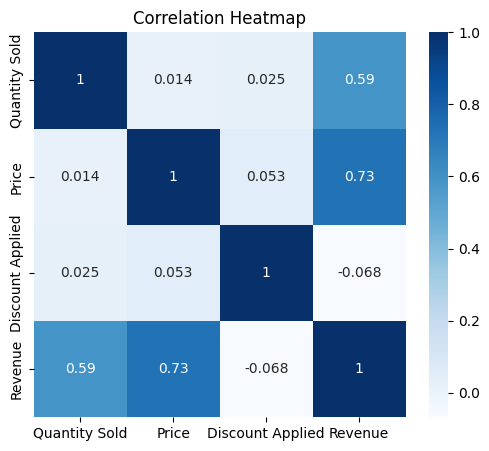

In [27]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(
    df[["Quantity Sold","Price","Discount Applied","Revenue"]].corr(),
    annot=True,
    cmap="Blues"
)
plt.title("Correlation Heatmap")
plt.show()

## Business Insights & Recommendations

• Books and Toys generated the highest overall revenue among all product categories.

• Monthly revenue shows noticeable variations, indicating seasonal sales trends.

• Credit Card is the most preferred payment method among customers.

• Higher product prices contribute significantly to increased revenue.

• Discounts have only a weak impact on revenue, as shown in the correlation analysis.

• Businesses should focus on promoting high-performing product categories and retaining loyal customers to maximize future revenue.

## Conclusion

This project successfully analyzed an e-commerce sales dataset using Python, Pandas, Matplotlib and Seaborn. The data was cleaned, transformed and explored using various visualization techniques. The analysis helped identify top-selling products, monthly revenue trends, customer purchasing behavior, payment preferences and category-wise performance. These insights can support businesses in making informed decisions, improving marketing strategies and increasing overall sales performance.